In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import re

In [2]:
RAW_PATH = r"E:\third semester\second term\Computer Vision\project\face-recognition-attendance\data\raw"
PROCESSED_PATH = r"E:\third semester\second term\Computer Vision\project\face-recognition-attendance\data\processed"
RESULTS_PATH = r"E:\third semester\second term\Computer Vision\project\face-recognition-attendance\outputs\results\preprocessing"

# Path to Haar Cascade XML file (bundled with OpenCV)
CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

print("Paths defined ✅")
print(f"Cascade file: {CASCADE_PATH}")

Paths defined ✅
Cascade file: c:\Users\Lenovo\anaconda3\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


##  Load Haar Cascade Classifier

In [4]:
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

if face_cascade.empty():
    raise RuntimeError("❌ Failed to load cascade. Check CASCADE_PATH.")
else:
    print("Haar Cascade loaded ✅")
    print(f"File: {CASCADE_PATH}")

Haar Cascade loaded ✅
File: c:\Users\Lenovo\anaconda3\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


##  4) Load Images

In [5]:
def natural_sort_key(text):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", text)]


def load_processed(folder, extensions=(".pgm", ".jpg", ".png")):
    """
    Load from flat processed folder.
    Only loads *_gaussian.pgm files to avoid duplicates.
    Returns list of (filename, subject_id, grayscale_array).
    """
    items = []
    if not os.path.isdir(folder):
        return items
    for fname in sorted(os.listdir(folder), key=natural_sort_key):
        if not fname.endswith("_gaussian.pgm"):
            continue
        path = os.path.join(folder, fname)
        img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            items.append((fname, "s1", img))   # processed only saved s1
    return items


def load_raw(root, extensions=(".pgm", ".jpg", ".png")):
    """
    Load from nested raw folder (ORL layout: root/sN/image.pgm).
    Returns list of (filename, subject_id, grayscale_array).
    """
    items = []
    if not os.path.isdir(root):
        return items
    for sub in sorted(os.listdir(root), key=natural_sort_key):
        sub_path = os.path.join(root, sub)
        if not os.path.isdir(sub_path):
            continue
        for fname in sorted(os.listdir(sub_path), key=natural_sort_key):
            if any(fname.lower().endswith(ext) for ext in extensions):
                path = os.path.join(sub_path, fname)
                img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    items.append((fname, sub, img))
    return items


# ── Decide which source to use ───────────────────────────────────────────
# NOTE: processed folder only contains s1 (10 images from preprocessing module)
# We need all 400 images, so we prefer raw when processed is incomplete.

processed_images = load_processed(PROCESSED_PATH)

if len(processed_images) >= 100:           # full dataset was preprocessed
    images = processed_images
    source_label = "processed (Gaussian)"
else:
    if processed_images:
        print(f"⚠️  Processed folder has only {len(processed_images)} images "
              f"(only s1 was saved by the preprocessing module).")
    print("→ Loading full dataset from raw/ instead.")
    images = load_raw(RAW_PATH)
    source_label = "raw"

if not images:
    raise FileNotFoundError(
        "No images found. Run the preprocessing notebook first, or check your paths."
    )

print(f"\nLoaded {len(images)} images from '{source_label}' folder ✅")
subjects = sorted(set(sub for _, sub, _ in images), key=natural_sort_key)
print(f"Subjects found: {len(subjects)} → {subjects[:5]} ...")

⚠️  Processed folder has only 10 images (only s1 was saved by the preprocessing module).
→ Loading full dataset from raw/ instead.

Loaded 400 images from 'raw' folder ✅
Subjects found: 40 → ['s1', 's2', 's3', 's4', 's5'] ...


##  5) Preprocessing: CLAHE Before Detection

CLAHE enhancer ready ✅


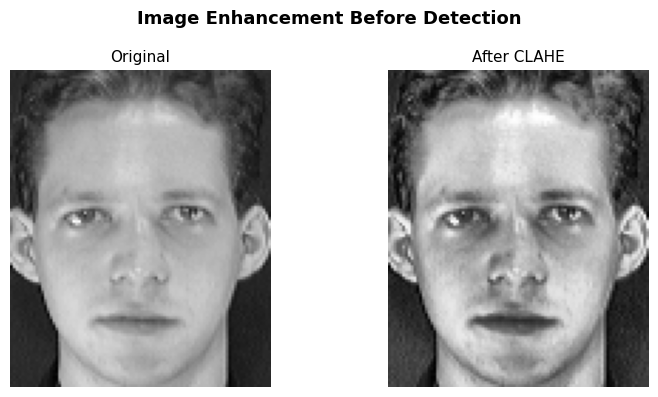

In [6]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

def enhance_for_detection(img_gray):
    """Apply CLAHE to improve contrast before face detection."""
    return clahe.apply(img_gray)

print("CLAHE enhancer ready ✅")

# Visual comparison: original vs enhanced
sample_img = images[0][2]
sample_enhanced = enhance_for_detection(sample_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title("Original", fontsize=11)
axes[0].axis('off')

axes[1].imshow(sample_enhanced, cmap='gray')
axes[1].set_title("After CLAHE", fontsize=11)
axes[1].axis('off')

plt.suptitle("Image Enhancement Before Detection", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  6) Detection Helper Functions

In [7]:
def detect_faces(img_gray, scale_factor=1.05, min_neighbors=3, min_size=(20, 20)):
    """
    Haar Cascade detection with padding trick for the ORL dataset.
    
    ORL images are 92x112 px — the face fills the ENTIRE frame.
    The cascade needs some background/context around the face to fire.
    Solution: pad the image with a black border before detection,
    then adjust bounding box coordinates back to original space.
    """
    # Add 30px black border on all sides so cascade has context
    PAD = 30
    padded = cv2.copyMakeBorder(
        img_gray, PAD, PAD, PAD, PAD,
        borderType=cv2.BORDER_CONSTANT, value=0
    )
    enhanced = clahe.apply(padded)

    result = face_cascade.detectMultiScale(
        enhanced,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size,
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    if len(result) == 0:
        return []

    # Subtract padding offset to get coords in original image space
    corrected = []
    h_orig, w_orig = img_gray.shape
    for (x, y, w, h) in result:
        x2 = max(0, x - PAD)
        y2 = max(0, y - PAD)
        w2 = min(w, w_orig - x2)
        h2 = min(h, h_orig - y2)
        corrected.append((x2, y2, w2, h2))
    return corrected


def draw_detections(img_gray, faces):
    """Return an RGB copy of img_gray with green rectangles around detected faces."""
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    for (x, y, w, h) in faces:
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 220, 0), 2)
    return img_rgb


def show_detection_grid(entries, cols=3, title="Face Detection Results"):
    """
    entries : list of (img_gray, faces, label)
    Green box = detected face | Red title = no face detected
    """
    if not entries:
        print("⚠️  Nothing to display — the entries list is empty.")
        return

    rows = max(1, (len(entries) + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    for i, (img_gray, faces, label) in enumerate(entries):
        axes[i].imshow(draw_detections(img_gray, faces))
        color  = "green" if len(faces) > 0 else "red"
        status = f"{len(faces)} face(s)" if len(faces) > 0 else "❌ not detected"
        axes[i].set_title(f"{label}{status}", fontsize=9, color=color)
        axes[i].axis("off")

    for j in range(len(entries), len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Helper functions defined ✅")


Helper functions defined ✅


##  7) Run Face Detection on All Images

In [8]:
results        = []
sample_entries = []       # (img, faces, label) for grid — 9 samples
MAX_GRID       = 9

# Pick representative samples: 1 from every ~4th subject
sample_subjects = set(subjects[::4][:MAX_GRID])
sampled = set()

for fname, subject, img in images:
    faces = detect_faces(img)
    results.append({
        "subject":        subject,
        "image":          fname,
        "faces_detected": len(faces)
    })

    if subject in sample_subjects and subject not in sampled:
        label = f"{subject}/{fname}"
        sample_entries.append((img, faces, label))
        sampled.add(subject)

df = pd.DataFrame(results)
total      = len(df)
detected   = (df["faces_detected"] > 0).sum()
undetected = total - detected

print(f"Detection complete ✅")
print(f"  Total images  : {total}")
print(f"  Face detected : {detected}")
print(f"  Not detected  : {undetected}")
print(f"  Detection rate: {detected / total * 100:.1f}%")

Detection complete ✅
  Total images  : 400
  Face detected : 400
  Not detected  : 0
  Detection rate: 100.0%


##  8) Display Detected Faces

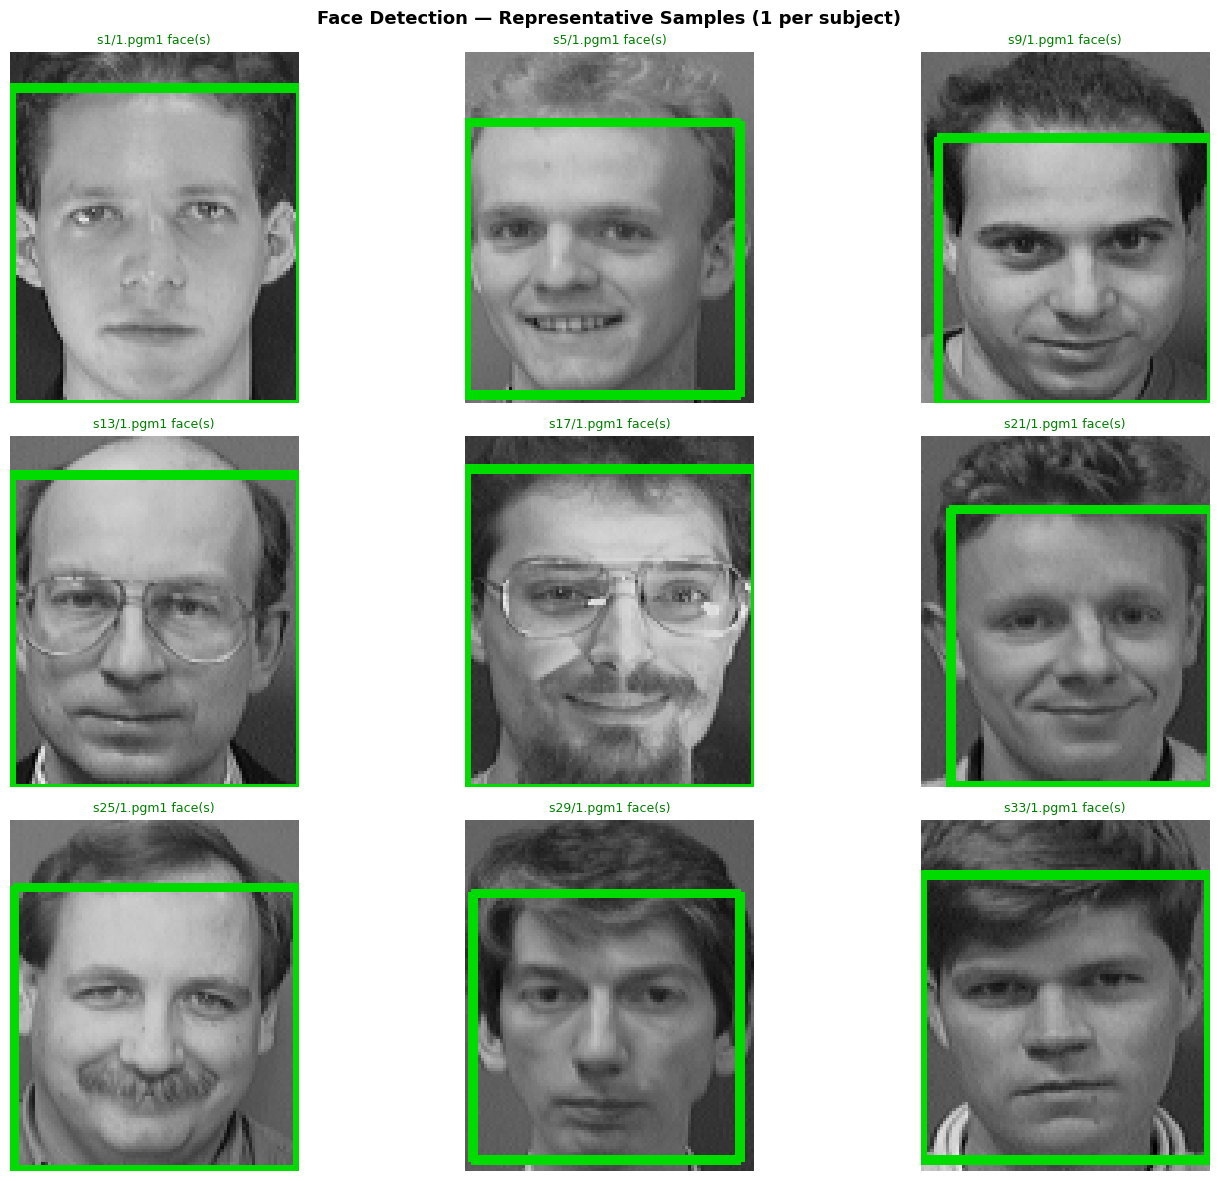

In [9]:
show_detection_grid(
    sample_entries,
    cols=3,
    title="Face Detection — Representative Samples (1 per subject)"
)

##  9) Tune Detection Parameters

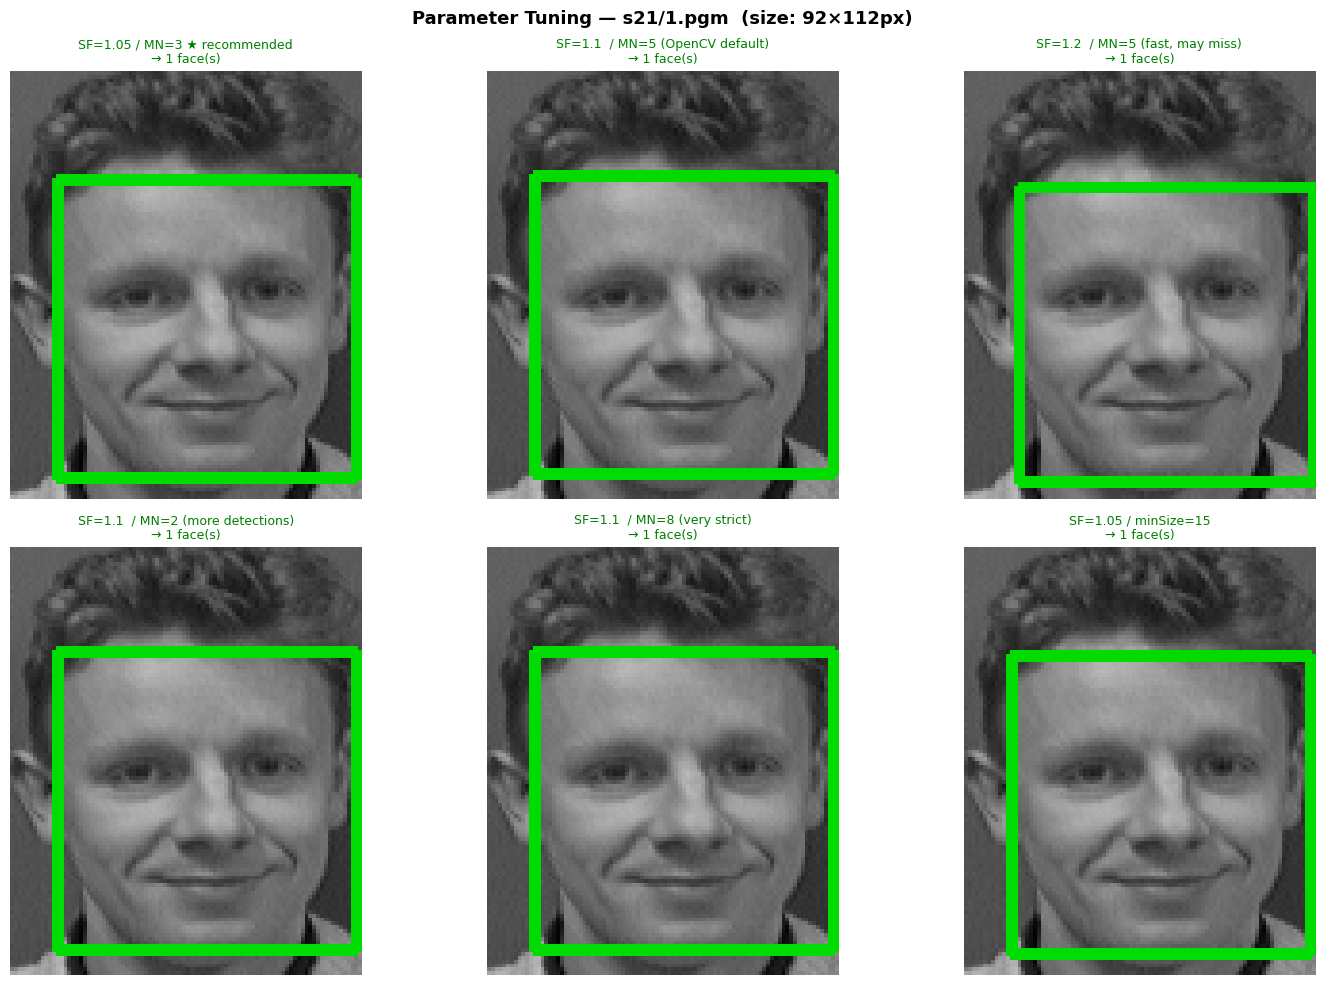

In [10]:
# Use the middle image of the dataset as test image
mid_idx = len(images) // 2
test_fname, test_subject, test_img = images[mid_idx]

configs = [
    dict(scale_factor=1.05, min_neighbors=3, min_size=(20, 20), label="SF=1.05 / MN=3 ★ recommended"),
    dict(scale_factor=1.1,  min_neighbors=5, min_size=(30, 30), label="SF=1.1  / MN=5 (OpenCV default)"),
    dict(scale_factor=1.2,  min_neighbors=5, min_size=(30, 30), label="SF=1.2  / MN=5 (fast, may miss)"),
    dict(scale_factor=1.1,  min_neighbors=2, min_size=(30, 30), label="SF=1.1  / MN=2 (more detections)"),
    dict(scale_factor=1.1,  min_neighbors=8, min_size=(30, 30), label="SF=1.1  / MN=8 (very strict)"),
    dict(scale_factor=1.05, min_neighbors=3, min_size=(15, 15), label="SF=1.05 / minSize=15"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cfg in enumerate(configs):
    enhanced = enhance_for_detection(test_img)
    faces = face_cascade.detectMultiScale(
        enhanced,
        scaleFactor=cfg["scale_factor"],
        minNeighbors=cfg["min_neighbors"],
        minSize=cfg["min_size"],
        flags=cv2.CASCADE_SCALE_IMAGE
    )
    faces = faces if len(faces) > 0 else []
    axes[i].imshow(draw_detections(test_img, faces))
    color = "green" if len(faces) == 1 else ("orange" if len(faces) > 1 else "red")
    axes[i].set_title(f"{cfg['label']}\n→ {len(faces)} face(s)", fontsize=9, color=color)
    axes[i].axis("off")

plt.suptitle(
    f"Parameter Tuning — {test_subject}/{test_fname}  (size: {test_img.shape[1]}×{test_img.shape[0]}px)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

##  10) Summary Statistics

In [11]:
# ── Overall summary ──────────────────────────────────────────────────────
print("=" * 45)
print("         DETECTION SUMMARY")
print("=" * 45)
print(f"  Total images    : {total}")
print(f"  Face detected   : {detected}")
print(f"  No face found   : {undetected}")
print(f"  Detection rate  : {detected / total * 100:.1f}%")
print("=" * 45)

# ── Per-subject breakdown ────────────────────────────────────────────────
subject_df = df.groupby("subject").agg(
    total_images=("faces_detected", "count"),
    faces_found=("faces_detected", lambda x: (x > 0).sum())
).reset_index()
subject_df["missed"] = subject_df["total_images"] - subject_df["faces_found"]
subject_df["rate_%"] = (subject_df["faces_found"] / subject_df["total_images"] * 100).round(1)

print("\nPer-subject detection rate:")
print(subject_df.to_string(index=False))

# ── Hard cases ───────────────────────────────────────────────────────────
hard = subject_df[subject_df["missed"] > 0].sort_values("missed", ascending=False)
if not hard.empty:
    print(f"\n⚠️  Subjects with missed detections ({len(hard)} subjects):")
    print(hard[["subject", "missed", "rate_%"]].to_string(index=False))
else:
    print("\n✅ All faces detected across all subjects!")

         DETECTION SUMMARY
  Total images    : 400
  Face detected   : 400
  No face found   : 0
  Detection rate  : 100.0%

Per-subject detection rate:
subject  total_images  faces_found  missed  rate_%
     s1            10           10       0   100.0
    s10            10           10       0   100.0
    s11            10           10       0   100.0
    s12            10           10       0   100.0
    s13            10           10       0   100.0
    s14            10           10       0   100.0
    s15            10           10       0   100.0
    s16            10           10       0   100.0
    s17            10           10       0   100.0
    s18            10           10       0   100.0
    s19            10           10       0   100.0
     s2            10           10       0   100.0
    s20            10           10       0   100.0
    s21            10           10       0   100.0
    s22            10           10       0   100.0
    s23            10          

##  11) Visualise Detection Rate Per Subject

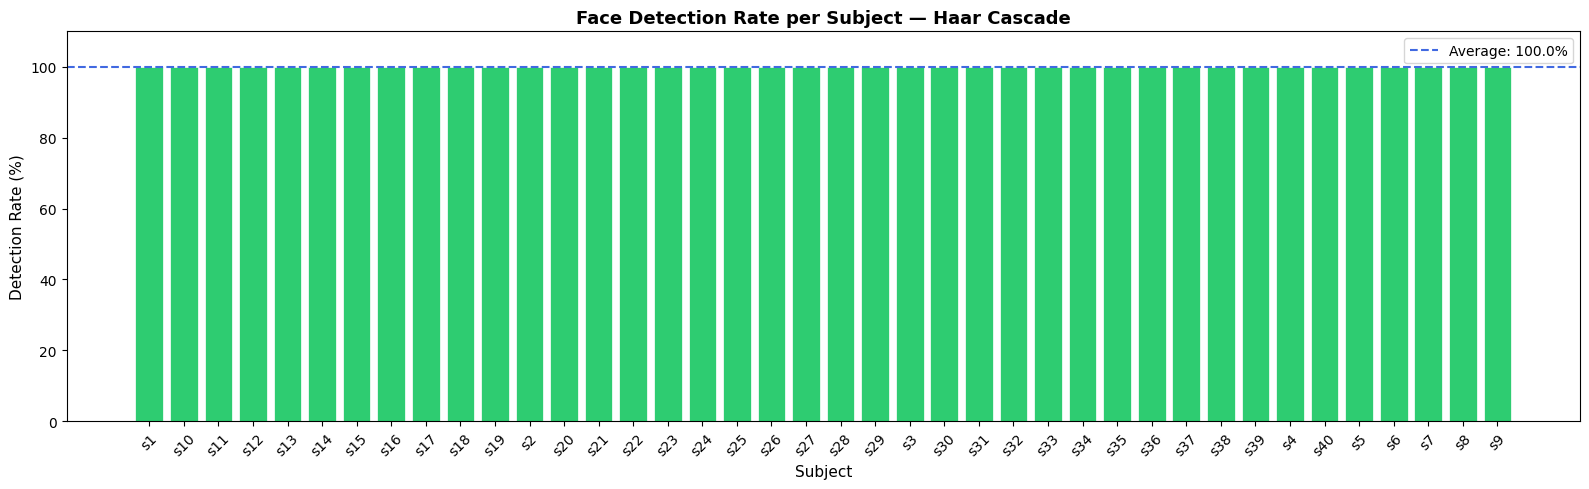

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))

colors = ["#2ecc71" if r == 100 else ("#f39c12" if r >= 70 else "#e74c3c")
          for r in subject_df["rate_%"]]

bars = ax.bar(subject_df["subject"], subject_df["rate_%"], color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(y=detected / total * 100, color="royalblue", linestyle="--",
           linewidth=1.5, label=f"Average: {detected / total * 100:.1f}%")
ax.set_xlabel("Subject", fontsize=11)
ax.set_ylabel("Detection Rate (%)", fontsize=11)
ax.set_title("Face Detection Rate per Subject — Haar Cascade", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)

# Add value labels on bars
for bar, val in zip(bars, subject_df["rate_%"]):
    if val < 100:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val:.0f}%", ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

##  13) Save Results to CSV

In [13]:
# Full per-image results
out_path = os.path.join(RESULTS_PATH, "face_detection_results.csv")
df.to_csv(out_path, index=False)
print(f"Per-image results saved → {out_path} ✅")

# Per-subject summary
summary_path = os.path.join(RESULTS_PATH, "detection_summary_by_subject.csv")
subject_df.to_csv(summary_path, index=False)
print(f"Subject summary saved  → {summary_path} ✅")

Per-image results saved → E:\third semester\second term\Computer Vision\project\face-recognition-attendance\outputs\results\preprocessing\face_detection_results.csv ✅
Subject summary saved  → E:\third semester\second term\Computer Vision\project\face-recognition-attendance\outputs\results\preprocessing\detection_summary_by_subject.csv ✅
